Step 1:Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

sns.set_style("whitegrid")

Step 2:Load Dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/train.csv")

print("Shape:", df.shape)
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

Step 3: Data Cleaning
Fill Missing Age with Median

In [4]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_4177/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


Fill Embarked Missing Values

In [5]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

Fill Cabin Missing Values

Since Cabin contains many missing values, create a category.

In [6]:
df['Cabin'] = df['Cabin'].fillna("Unknown")

Verify Missing Values

In [7]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Step 4: Encode Categorical Features
Encode Sex

In [8]:
sex_encoder = LabelEncoder()
df['Sex'] = sex_encoder.fit_transform(df['Sex'])

print(df['Sex'].unique())

[1 0]


Encode Passenger Class

In [9]:
df['Pclass'] = df['Pclass'].astype(int)

Encode Embarked

In [10]:
embarked_encoder = LabelEncoder()
df['Embarked'] = embarked_encoder.fit_transform(df['Embarked'])

Step 5: Normalize Numerical Columns

Normalize:

Age

Fare

SibSp

Parch

In [11]:
scaler = MinMaxScaler()

columns_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    1  0.271174  0.125   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.472229  0.125   
2                             Heikkinen, Miss. Laina    0  0.321438  0.000   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.434531  0.125   
4                           Allen, Mr. William Henry    1  0.434531  0.000   

   Parch            Ticket      Fare    Cabin  Embarked  
0    0.0         A/5 21171  0.014151  Unknown         2  
1    0.0          PC 17599  0.139136      C85         0  
2    0.0  STON/O2. 3101282  0.015469  Unknown         2  
3    0.0            113803  0.103644     C123         2  
4    0.0            3734

Step 6: Save Cleaned Dataset

In [12]:
df.to_csv("cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


VISUALIZATIONS
Visualization 1: Survival Count

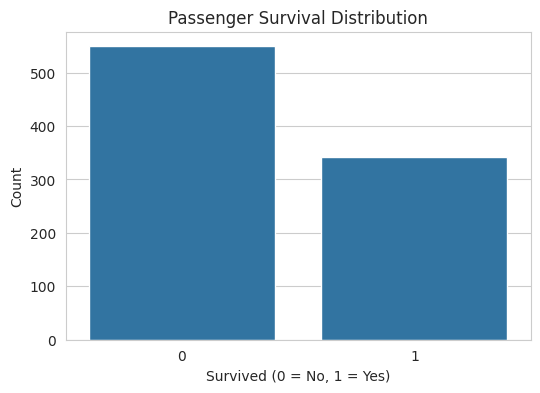

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Passenger Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

Visualization 2: Age vs Survival

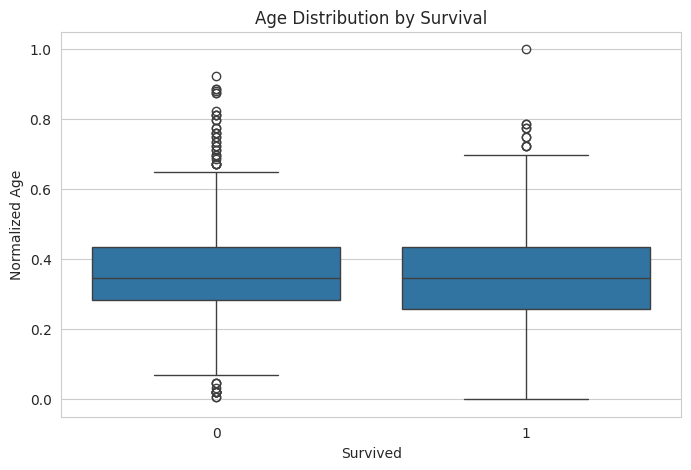

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Normalized Age")

plt.show()

Visualization 3: Fare Distribution

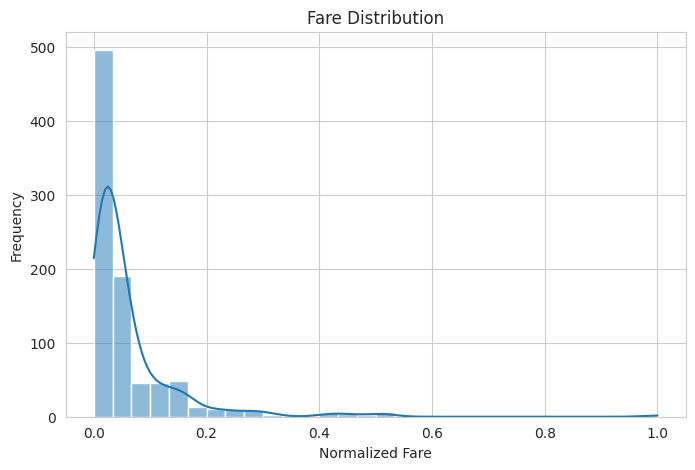

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Normalized Fare")
plt.ylabel("Frequency")

plt.show()

Visualization 4: Gender Ratio

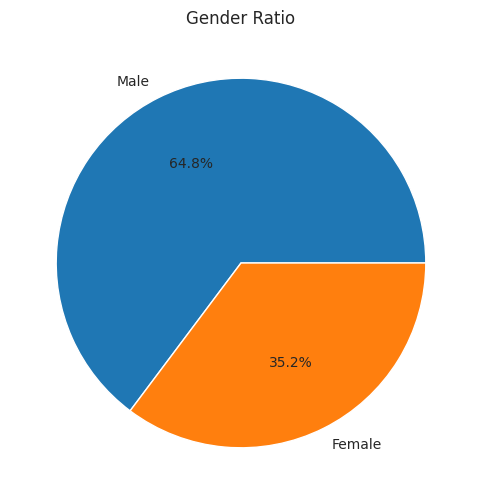

In [16]:
gender_counts = df['Sex'].value_counts()

labels = ['Male', 'Female']

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Gender Ratio")

plt.show()

Visualization 5: Survival by Passenger Class

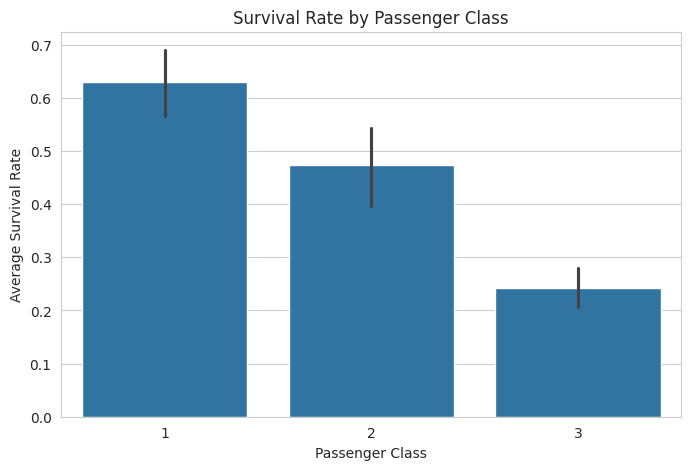

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Pclass',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival Rate")

plt.show()

Correlation Heatmap

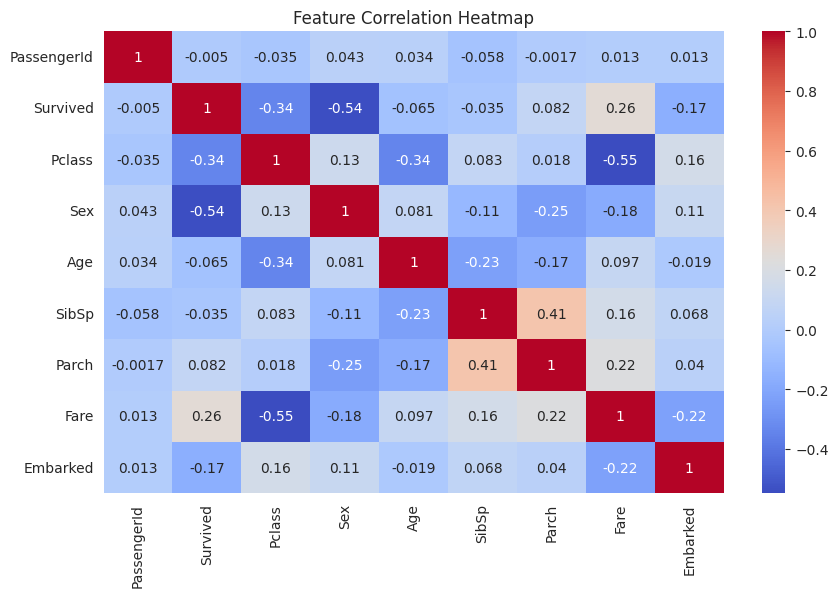

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()